In [ ]:
Import Libraries and Load Data

In [2]:
# Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
 
# Display settings
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
 
# Load the dataset — adjust the path to your CSV file
df = pd.read_csv('../data/train.csv')
 
# Show first 5 rows to confirm it loaded
df.head()


,ID,Store_id,Store_Type,Location_Type,Region_Code,Date,Holiday,Discount,#Order,Sales
0,T1000001,1,S1,L3,R1,01-01-2018,1,Yes,9,7011.84
1,T1000002,253,S4,L2,R1,01-01-2018,1,Yes,60,51789.12
2,T1000003,252,S3,L2,R1,01-01-2018,1,Yes,42,36868.20
3,T1000004,251,S2,L3,R1,01-01-2018,1,Yes,23,19715.16
4,T1000005,250,S2,L3,R4,01-01-2018,1,Yes,62,45614.52


In [ ]:
Basic Dataset Information

In [3]:
# How many rows and columns?
print('Dataset Shape:', df.shape)
 
# What columns exist and what type are they?
print('\nColumn Info:')
print(df.dtypes)
 
# How many missing values in each column?
print('\nMissing Values:')
print(df.isnull().sum())
 
# Basic statistics for numeric columns
print('\nStatistical Summary:')
df.describe()


Dataset Shape: (188340, 10)

Column Info:
ID                object
Store_id           int64
Store_Type        object
Location_Type     object
Region_Code       object
Date              object
Holiday            int64
Discount          object
#Order             int64
Sales            float64
dtype: object

Missing Values:
ID               0
Store_id         0
Store_Type       0
Location_Type    0
Region_Code      0
Date             0
Holiday          0
Discount         0
#Order           0
Sales            0
dtype: int64

Statistical Summary:


,Store_id,Holiday,#Order,Sales
count,188340.000000,188340.000000,188340.000000,188340.000000
mean,183.000000,0.131783,68.205692,42784.327982
std,105.366308,0.338256,30.467415,18456.708302
min,1.000000,0.000000,0.000000,0.000000
25%,92.000000,0.000000,48.000000,30426.000000
50%,183.000000,0.000000,63.000000,39678.000000
75%,274.000000,0.000000,82.000000,51909.000000
max,365.000000,1.000000,371.000000,247215.000000


In [ ]:
Data Cleaning & Type Conversion

In [5]:
# Convert Date column to proper datetime format
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
 
# Extract useful time features from the date
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek  # 0=Monday, 6=Sunday
df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)
 
# Convert 'Discount' column from Yes/No to 1/0
df['Discount'] = df['Discount'].map({'Yes': 1, 'No': 0})
 
# Check for duplicate rows
print('Duplicate rows:', df.duplicated().sum())
df.drop_duplicates(inplace=True)
 
# Check data after cleaning
print('\nData shape after cleaning:', df.shape)
print(df.head())


Duplicate rows: 0

Data shape after cleaning: (188340, 15)
         ID  Store_id Store_Type Location_Type Region_Code       Date  \
0  T1000001         1         S1            L3          R1 2018-01-01   
1  T1000002       253         S4            L2          R1 2018-01-01   
2  T1000003       252         S3            L2          R1 2018-01-01   
3  T1000004       251         S2            L3          R1 2018-01-01   
4  T1000005       250         S2            L3          R4 2018-01-01   

   Holiday  Discount  #Order     Sales  Year  Month  Day  DayOfWeek  \
0        1         1       9   7011.84  2018      1    1          0   
1        1         1      60  51789.12  2018      1    1          0   
2        1         1      42  36868.20  2018      1    1          0   
3        1         1      23  19715.16  2018      1    1          0   
4        1         1      62  45614.52  2018      1    1          0   

   WeekOfYear  
0           1  
1           1  
2           1  
3          

In [ ]:
Univariate Analysis 

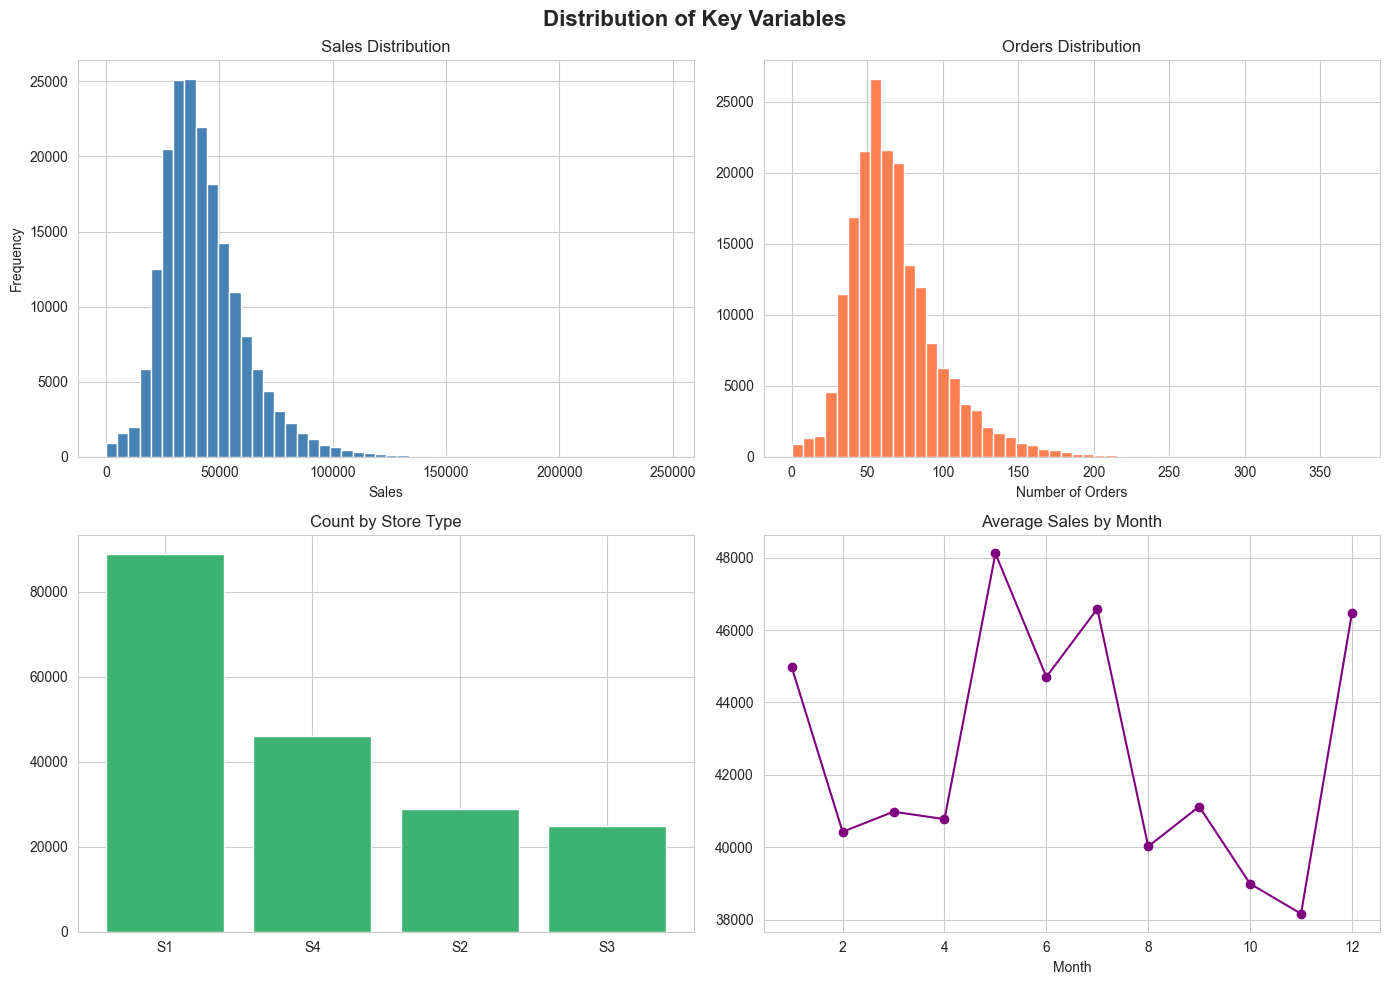

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribution of Key Variables', fontsize=16, fontweight='bold')
 
# Sales distribution
axes[0,0].hist(df['Sales'], bins=50, color='steelblue', edgecolor='white')
axes[0,0].set_title('Sales Distribution')
axes[0,0].set_xlabel('Sales')
axes[0,0].set_ylabel('Frequency')
 
# Orders distribution
axes[0,1].hist(df['#Order'], bins=50, color='coral', edgecolor='white')
axes[0,1].set_title('Orders Distribution')
axes[0,1].set_xlabel('Number of Orders')
 
# Store Type distribution
store_counts = df['Store_Type'].value_counts()
axes[1,0].bar(store_counts.index, store_counts.values, color='mediumseagreen')
axes[1,0].set_title('Count by Store Type')
 
# Monthly sales
monthly = df.groupby('Month')['Sales'].mean()
axes[1,1].plot(monthly.index, monthly.values, marker='o', color='purple')
axes[1,1].set_title('Average Sales by Month')
axes[1,1].set_xlabel('Month')
 
plt.tight_layout()
plt.savefig('../notebooks/univariate_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
Time Series Analysis

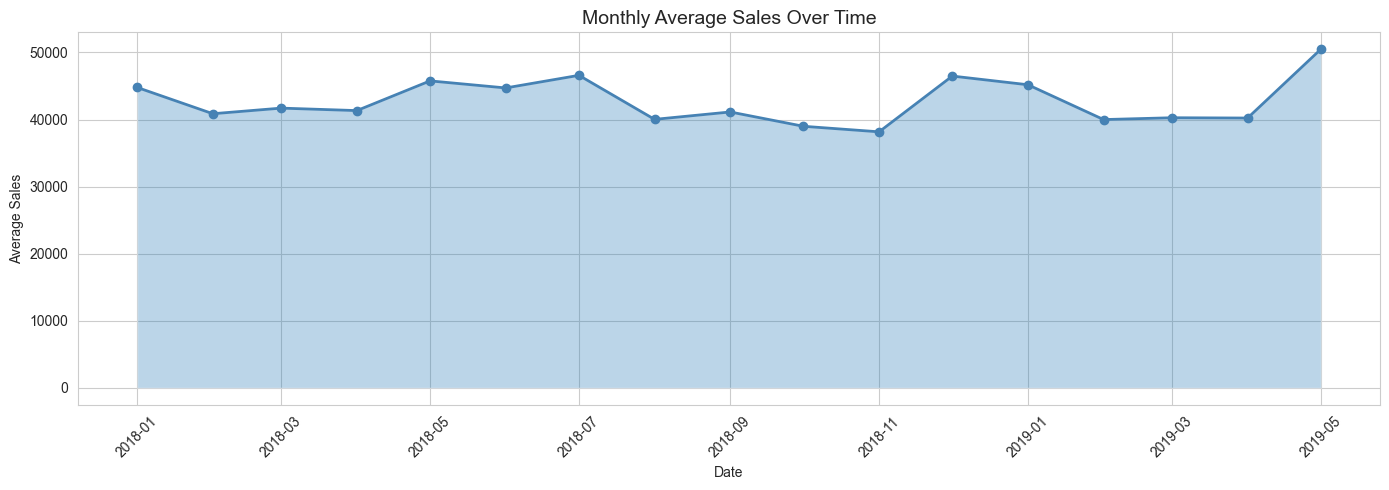

In [7]:
monthly_sales = df.groupby(['Year', 'Month'])['Sales'].mean().reset_index()
monthly_sales['Date'] = pd.to_datetime(monthly_sales[['Year','Month']].assign(Day=1))
 
plt.figure(figsize=(14, 5))
plt.plot(monthly_sales['Date'], monthly_sales['Sales'],
         marker='o', linewidth=2, color='steelblue')
plt.fill_between(monthly_sales['Date'], monthly_sales['Sales'], alpha=0.3)
plt.title('Monthly Average Sales Over Time', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Average Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../notebooks/time_series.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
Bivariate Analysis 

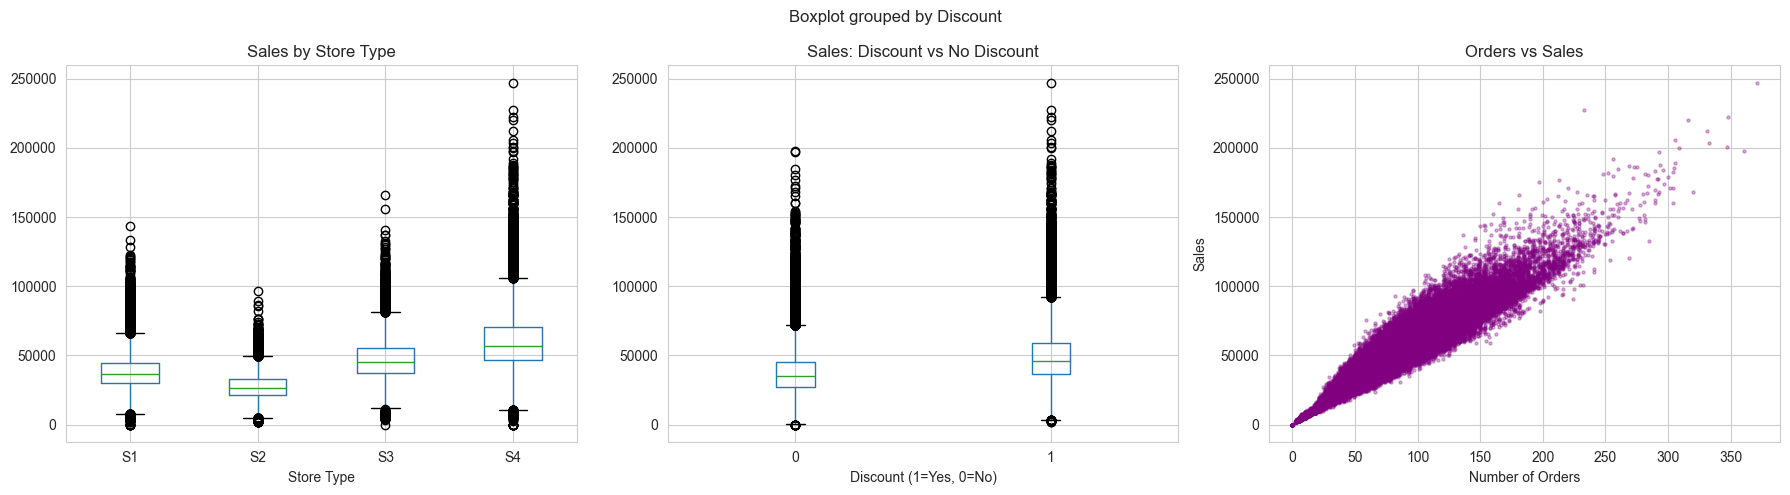

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Bivariate Analysis', fontsize=14, fontweight='bold')
 
# Sales by Store Type
df.boxplot(column='Sales', by='Store_Type', ax=axes[0])
axes[0].set_title('Sales by Store Type')
axes[0].set_xlabel('Store Type')
 
# Sales by Discount
df.boxplot(column='Sales', by='Discount', ax=axes[1])
axes[1].set_title('Sales: Discount vs No Discount')
axes[1].set_xlabel('Discount (1=Yes, 0=No)')
 
# Orders vs Sales scatter
axes[2].scatter(df['#Order'], df['Sales'], alpha=0.3, color='purple', s=5)
axes[2].set_title('Orders vs Sales')
axes[2].set_xlabel('Number of Orders')
axes[2].set_ylabel('Sales')
 
plt.tight_layout()
plt.savefig('../notebooks/bivariate_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
Correlation Heatmap

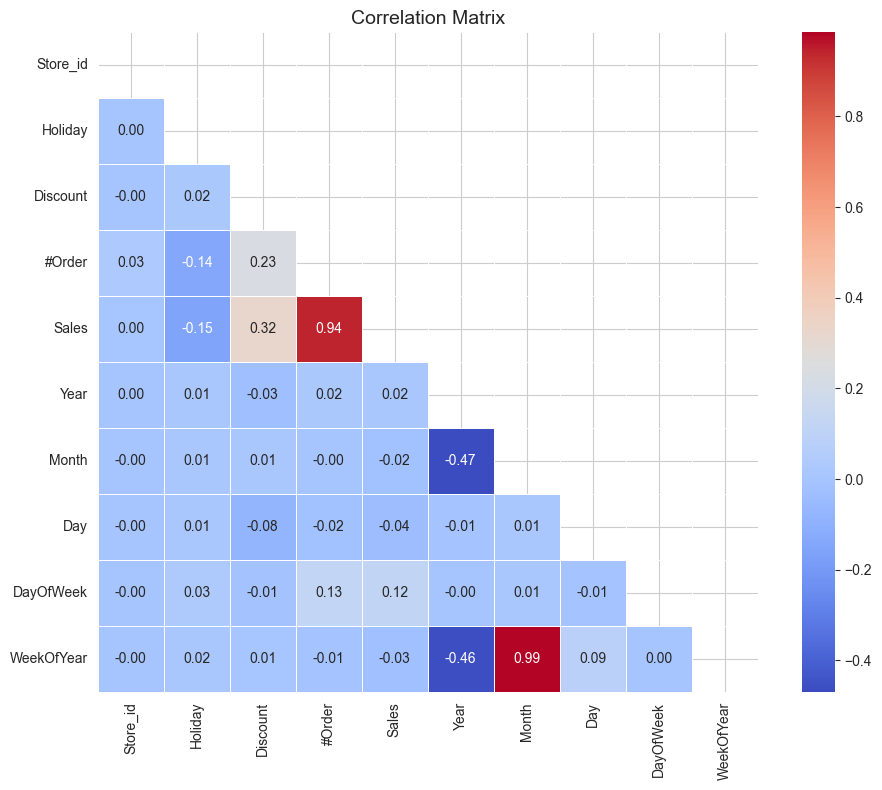

Correlation with Sales:
Sales         1.000000
#Order        0.941601
Discount      0.323906
DayOfWeek     0.119129
Year          0.018284
Store_id      0.004377
Month        -0.018092
WeekOfYear   -0.025094
Day          -0.038969
Holiday      -0.154779
Name: Sales, dtype: float64


In [9]:
# Only select numeric columns for correlation
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[numeric_cols].corr()
 
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # hide upper triangle
sns.heatmap(corr_matrix, annot=True, fmt='.2f',
            cmap='coolwarm', mask=mask,
            linewidths=0.5, square=True)
plt.title('Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.savefig('../notebooks/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
 
# Print correlation with Sales specifically
print('Correlation with Sales:')
print(corr_matrix['Sales'].sort_values(ascending=False))


In [ ]:
Outlier Detection

Outlier Detection:
Sales: 5843 outliers (3.10%)
#Order: 7089 outliers (3.76%)


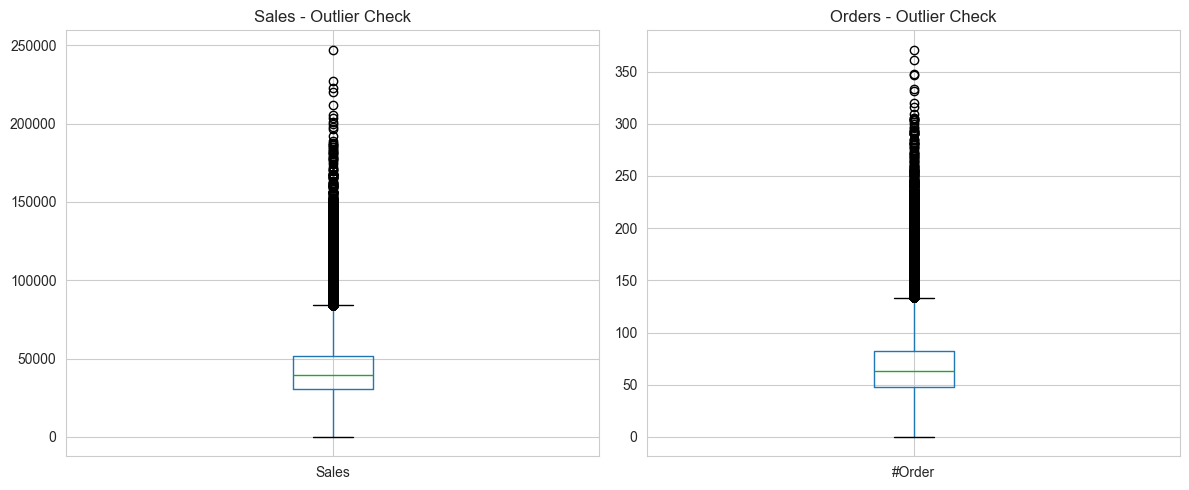

In [10]:
# Detect outliers using IQR method
def detect_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower) | (data[column] > upper)]
    print(f'{column}: {len(outliers)} outliers ({len(outliers)/len(data)*100:.2f}%)')
    return lower, upper
 
print('Outlier Detection:')
for col in ['Sales', '#Order']:
    detect_outliers(df, col)
 
# Box plots to visualize outliers
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
df.boxplot(column='Sales', ax=axes[0])
axes[0].set_title('Sales - Outlier Check')
df.boxplot(column='#Order', ax=axes[1])
axes[1].set_title('Orders - Outlier Check')
plt.tight_layout()
plt.show()


In [ ]:
Hypothesis Testing (5 Tests)

In [ ]:
Test 1: Do Discounts Increase Sales?

In [11]:
# Test: Does offering a discount lead to significantly higher sales?
sales_discount = df[df['Discount'] == 1]['Sales']
sales_no_discount = df[df['Discount'] == 0]['Sales']
 
t_stat, p_value = stats.ttest_ind(sales_discount, sales_no_discount)
 
print('=== HYPOTHESIS TEST 1: Discount Impact on Sales ===')
print(f'Mean Sales WITH Discount:    {sales_discount.mean():.2f}')
print(f'Mean Sales WITHOUT Discount: {sales_no_discount.mean():.2f}')
print(f'T-Statistic: {t_stat:.4f}')
print(f'P-Value:     {p_value:.6f}')
 
if p_value < 0.05:
    print('CONCLUSION: Discount has a SIGNIFICANT effect on sales (p < 0.05)')
else:
    print('CONCLUSION: No significant effect of discount on sales (p >= 0.05)')


=== HYPOTHESIS TEST 1: Discount Impact on Sales ===
Mean Sales WITH Discount:    49426.50
Mean Sales WITHOUT Discount: 37403.68
T-Statistic: 148.5785
P-Value:     0.000000
CONCLUSION: Discount has a SIGNIFICANT effect on sales (p < 0.05)


In [ ]:
Test 2: Do Holidays Increase Sales?

In [12]:
# Test: Are sales higher on holidays?
sales_holiday = df[df['Holiday'] == 1]['Sales']
sales_regular = df[df['Holiday'] == 0]['Sales']
 
t_stat, p_value = stats.ttest_ind(sales_holiday, sales_regular)
 
print('=== HYPOTHESIS TEST 2: Holiday Impact on Sales ===')
print(f'Mean Sales on Holidays:     {sales_holiday.mean():.2f}')
print(f'Mean Sales on Regular Days: {sales_regular.mean():.2f}')
print(f'P-Value: {p_value:.6f}')
 
if p_value < 0.05:
    print('CONCLUSION: Holiday has a SIGNIFICANT effect on sales (p < 0.05)')
else:
    print('CONCLUSION: No significant effect found (p >= 0.05)')


=== HYPOTHESIS TEST 2: Holiday Impact on Sales ===
Mean Sales on Holidays:     35451.88
Mean Sales on Regular Days: 43897.29
P-Value: 0.000000
CONCLUSION: Holiday has a SIGNIFICANT effect on sales (p < 0.05)


In [ ]:
Test 3: Sales Differences Across Store Types (ANOVA)

In [13]:
# Test: Do different store types have different sales? (ANOVA)
groups = [df[df['Store_Type'] == t]['Sales'] for t in df['Store_Type'].unique()]
 
f_stat, p_value = stats.f_oneway(*groups)
 
print('=== HYPOTHESIS TEST 3: Sales Across Store Types (ANOVA) ===')
for t in df['Store_Type'].unique():
    mean = df[df['Store_Type'] == t]['Sales'].mean()
    print(f'Store Type {t}: Mean Sales = {mean:.2f}')
print(f'F-Statistic: {f_stat:.4f}')
print(f'P-Value:     {p_value:.6f}')
 
if p_value < 0.05:
    print('CONCLUSION: Sales differ SIGNIFICANTLY across store types (p < 0.05)')
else:
    print('CONCLUSION: No significant difference across store types (p >= 0.05)')


=== HYPOTHESIS TEST 3: Sales Across Store Types (ANOVA) ===
Store Type S1: Mean Sales = 37676.51
Store Type S4: Mean Sales = 59945.69
Store Type S3: Mean Sales = 47063.07
Store Type S2: Mean Sales = 27530.83
F-Statistic: 35123.6441
P-Value:     0.000000
CONCLUSION: Sales differ SIGNIFICANTLY across store types (p < 0.05)


In [ ]:
Test 4: Regional Sales Variability

In [14]:
# Test: Does sales vary significantly across regions?
# Using Kruskal-Wallis (non-parametric version of ANOVA — safer for non-normal data)
regions = [df[df['Region_Code'] == r]['Sales'] for r in df['Region_Code'].unique()]
 
stat, p_value = stats.kruskal(*regions)
 
print('=== HYPOTHESIS TEST 4: Regional Sales Variability ===')
for r in sorted(df['Region_Code'].unique()):
    mean = df[df['Region_Code'] == r]['Sales'].mean()
    print(f'Region {r}: Mean Sales = {mean:.2f}')
print(f'Kruskal-Wallis Stat: {stat:.4f}')
print(f'P-Value:             {p_value:.6f}')
 
if p_value < 0.05:
    print('CONCLUSION: Significant regional variation in sales (p < 0.05)')
else:
    print('CONCLUSION: No significant regional variation (p >= 0.05)')


=== HYPOTHESIS TEST 4: Regional Sales Variability ===
Region R1: Mean Sales = 46765.49
Region R2: Mean Sales = 40054.85
Region R3: Mean Sales = 42144.52
Region R4: Mean Sales = 39743.43
Kruskal-Wallis Stat: 3968.0636
P-Value:             0.000000
CONCLUSION: Significant regional variation in sales (p < 0.05)


In [ ]:
Test 5: Correlation Between Orders and Sales

In [15]:
# Test: Does a higher number of orders mean higher sales?
corr, p_value = stats.pearsonr(df['#Order'], df['Sales'])
 
print('=== HYPOTHESIS TEST 5: Orders vs Sales Correlation ===')
print(f'Pearson Correlation Coefficient: {corr:.4f}')
print(f'P-Value: {p_value:.6f}')
 
if p_value < 0.05:
    print(f'CONCLUSION: Significant correlation found (r = {corr:.4f}, p < 0.05)')
    if corr > 0:
        print('Direction: Positive — More orders = Higher sales')
    else:
        print('Direction: Negative — More orders = Lower sales (unexpected!)')
else:
    print('CONCLUSION: No significant correlation found (p >= 0.05)')


=== HYPOTHESIS TEST 5: Orders vs Sales Correlation ===
Pearson Correlation Coefficient: 0.9416
P-Value: 0.000000
CONCLUSION: Significant correlation found (r = 0.9416, p < 0.05)
Direction: Positive — More orders = Higher sales


In [ ]:
Summary Table of Hypothesis Tests

In [16]:
# Create a summary of all hypothesis test results
results = {
    'Test': ['Discounts → Sales', 'Holidays → Sales', 'Store Type → Sales',
             'Region → Sales', 'Orders ↔ Sales'],
    'Method': ['T-Test', 'T-Test', 'ANOVA', 'Kruskal-Wallis', 'Pearson'],
    'Significant': ['Yes/No', 'Yes/No', 'Yes/No', 'Yes/No', 'Yes/No']
}
# Replace Yes/No with your actual results after running tests above
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))


              Test         Method Significant
 Discounts → Sales         T-Test      Yes/No
  Holidays → Sales         T-Test      Yes/No
Store Type → Sales          ANOVA      Yes/No
    Region → Sales Kruskal-Wallis      Yes/No
    Orders ↔ Sales        Pearson      Yes/No
